In [44]:
%%loadFromPOM
<dependency>
    <groupId>tech.tablesaw</groupId>
    <artifactId>tablesaw-core</artifactId>
    <version>0.32.6</version>
</dependency>

<dependency>
    <groupId>org.slf4j</groupId>
    <artifactId>slf4j-simple</artifactId>
    <version>1.7.25</version>
</dependency>

<dependency>
    <groupId>org.knowm.xchart</groupId>
    <artifactId>xchart</artifactId>
    <version>3.5.4</version>
</dependency>

In [45]:
%maven org.knowm.xchart:xchart:3.8.0

In [46]:
import tech.tablesaw.api.*;

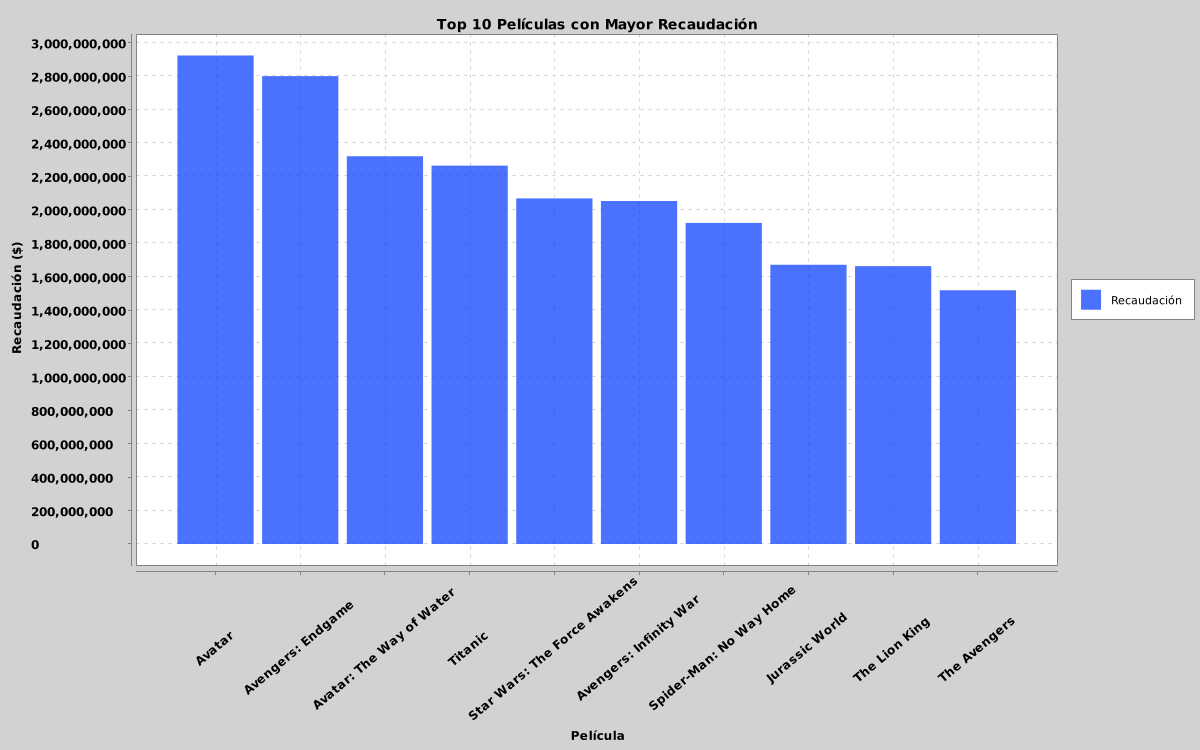

In [ ]:
import tech.tablesaw.api.*;
import org.knowm.xchart.*;
import java.util.*;

// 1. Leer CSV
Table peliculas = Table.read().csv("/workspaces/EDA_Analisis de datos en java/movies.csv");

// 2. Ordenar por recaudación (revenue) y sacar las top 10
Table topRevenue = peliculas.sortDescendingOn("revenue").first(10);

// 3. Extraer columnas (Títulos y Recaudación)
String[] titulos = topRevenue.textColumn("title").asObjectArray();
double[] recaudacion = topRevenue.numberColumn("revenue").asDoubleArray();

// 4. Convertir a listas para XChart
List<String> xData = Arrays.asList(titulos);
List<Double> yData = new ArrayList<>();
for (double r : recaudacion) {
    yData.add(r);
}

// 5. Creamos el gráfico de barras
CategoryChart chart = new CategoryChartBuilder()
        .width(1200)
        .height(750)
        .title("Top 10 Películas con Mayor Recaudación")
        .xAxisTitle("Película")
        .yAxisTitle("Recaudación ($)")
        .build();


// Formateo de dinero
chart.getStyler().setYAxisDecimalPattern("#,###");

// Inclinacion
chart.getStyler().setXAxisLabelRotation(40);



// 6. Agregar datos
chart.addSeries("Recaudación", xData, yData);

// 7. Mostrar en Jupyter
BitmapEncoder.getBufferedImage(chart)